In [1]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])
df["job_skills"]=df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



c:\Users\BAJWA LAPTOPS\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
df_US = df[df['job_country'] == 'United States'].dropna(subset=['salary_year_avg'])
job_titles= df_US['job_title_short'].value_counts().index[0:6].tolist()
df_US_top_6 = df_US[df_US['job_title_short'].isin(job_titles)]
job_order= df_US_top_6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index



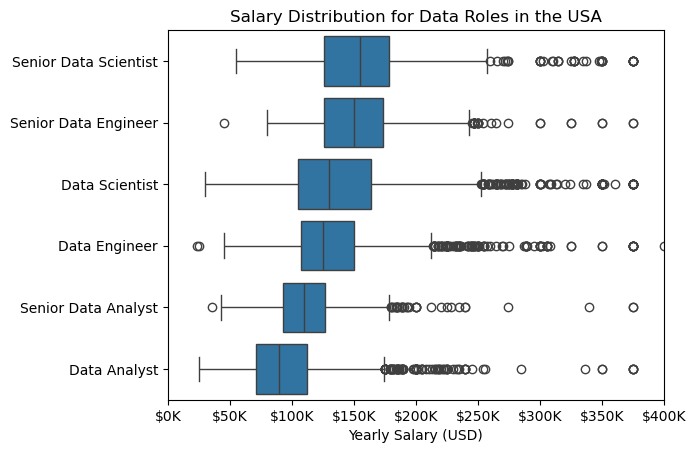

In [37]:
sns.boxplot(data=df_US_top_6, x='salary_year_avg', y='job_title_short', order=job_order)

plt.title("Salary Distribution for Data Roles in the USA")
plt.xlabel("Yearly Salary (USD)")
plt.ylabel("")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
plt.xlim(0, 400000)
plt.show()

Investigating Median Salary vs Skills for Data Analysis
---------

In [44]:
df_DA_US = df[
    (df['job_title'] == 'Data Analyst') & 
    (df['job_country'] == 'United States')
].copy()

df_DA_US=df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month
df_DA_US_explode = df_DA_US.explode('job_skills')

In [52]:
df_DA_top_pay=df_DA_US_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)
df_DA_top_pay=df_DA_top_pay.head(10)
df_DA_top_pay

,count,median
job_skills,,
golang,1,145000.0
elasticsearch,3,128500.0
redis,1,128500.0
dynamodb,1,115000.0
jupyter,5,115000.0
mongodb,14,115000.0
bitbucket,1,111175.0
ssis,23,110000.0
gcp,12,106250.0


In [50]:
df_DA_skills=df_DA_US_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills= df_DA_skills.head(10).sort_values(by='median', ascending=False)

df_DA_skills

,count,median
job_skills,,
aws,75,92500.0
python,408,90000.0
r,244,90000.0
tableau,398,90000.0
power bi,279,87500.0
sql,714,87500.0
sas,200,84078.5
excel,472,77500.0
powerpoint,102,77500.0


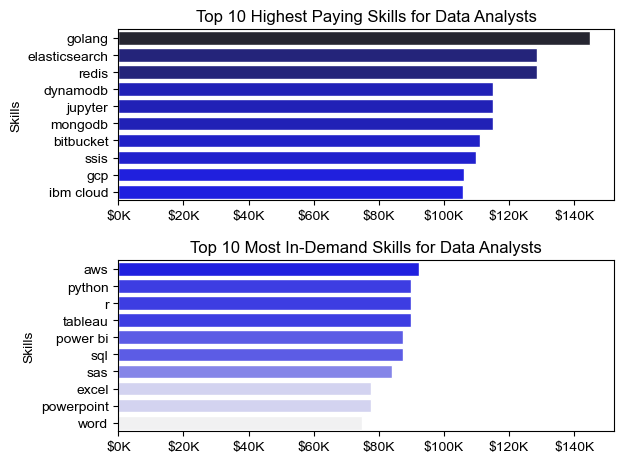

In [53]:
from matplotlib.ticker import FuncFormatter
fig, ax = plt.subplots(2,1)

sns.set_theme(style="ticks")  # Set Seaborn theme for better aesthetics

#skills_stat_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)

sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:blue_r', legend=False)
ax[0].set_title("Top 10 Highest Paying Skills for Data Analysts")
ax[0].set_xlabel("")
ax[0].set_ylabel("Skills")
#ax[0].invert_yaxis()  # Invert y-axis to have the highest pay at the top
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:,.0f}K'))  # Format x-axis as currency

#skills_stat_top_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='light:blue', legend=False)
ax[1].set_title("Top 10 Most In-Demand Skills for Data Analysts")
ax[1].set_xlabel("")
ax[1].set_ylabel("Skills")
#ax[1].invert_yaxis()  # Invert y-axis to have the most common skills at the top
ax[1].set_xlim(ax[0].get_xlim())  # Align x-axis limits for better comparison
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:,.0f}K'))  # Format x-axis as currency
plt.tight_layout()